<a href="https://colab.research.google.com/github/to-nakanishi/home_credit_default_risk/blob/main/home_credit_default_risk_05_ANALYZE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#0-1　基本設定
!pip install -q catboost==1.2.7

In [17]:
#0-2　基本設定
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool
import shap
import pickle
import gc
import warnings
import time
import os

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
#0-3　データ読込

train = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/home-credit-default-risk/加工データ/03FE2/train_FE2.zstd.parquet')
test  = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/home-credit-default-risk/加工データ/03FE2/test_FE2.zstd.parquet')

print(f"train: {train.shape}")
print(f"test:  {test.shape}")
print(f"TARGET分布:\n{train['TARGET'].value_counts(normalize=True)}")

train: (307511, 671)
test:  (48744, 670)
TARGET分布:
TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64


In [20]:
#1-1　データ復元　下準備（ID・ターゲット分離）

TARGET = "TARGET"
ID_COL = "SK_ID_CURR"

y = train[TARGET].values
test_ids = test[ID_COL].values

drop_cols = [TARGET, ID_COL] if ID_COL in train.columns else [TARGET]
X = train.drop(columns=drop_cols)
X_test = test.drop(columns=[c for c in drop_cols if c in test.columns])

# カラム順序を揃える
X_test = X_test[X.columns]
print(f"特徴量数: {X.shape[1]}")

# --- カテゴリ列の特定 ---
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"カテゴリ列数: {len(cat_cols)}")
if cat_cols:
    print(f"例: {cat_cols[:10]}")


# 不要になったデータフレームを削除
if 'train' in locals():
    del train
if 'test' in locals():
    del test
import gc
gc.collect()

特徴量数: 669
カテゴリ列数: 39
例: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


0

In [21]:
#1-2　データ復元　LGBM結果復元

SAVE_DIR = "/content/drive/MyDrive/home_credit_models_gpu"

oof_lgbm_df = pd.read_parquet(os.path.join(SAVE_DIR, "oof_lgbm.parquet"))
oof_lgbm = oof_lgbm_df["oof_lgbm"].values
y = oof_lgbm_df["TARGET"].values

pred_lgbm_df = pd.read_parquet(os.path.join(SAVE_DIR, "pred_lgbm.parquet"))
preds_lgbm = pred_lgbm_df["pred_lgbm"].values
test_ids = pred_lgbm_df["SK_ID_CURR"].values

oof_auc_lgbm = roc_auc_score(y, oof_lgbm)
print(f"LGBM OOF AUC (復元): {oof_auc_lgbm:.5f}")

# ---  重要度データの復元 (LGBM) ---
lgb_imp_raw = pd.read_parquet(os.path.join(SAVE_DIR, "lgbm_importance.parquet"))
lgb_imp = lgb_imp_raw.groupby('feature')['importance'].mean().reset_index()
lgb_imp['LGBM_pct'] = (lgb_imp['importance'] / lgb_imp['importance'].sum()) * 100

LGBM OOF AUC (復元): 0.79271


In [22]:
#1-3　データ復元　CAT結果復元

import glob

# CatBoost GPU版の復元
SAVE_DIR_CAT = "/content/drive/MyDrive/home_credit_models_gpu/home_credit_models_gpu_CAT"

oof_cb_df = pd.read_parquet(os.path.join(SAVE_DIR_CAT, "oof_catboost.parquet"))
oof_cb = oof_cb_df["oof_catboost"].values

pred_cb_df = pd.read_parquet(os.path.join(SAVE_DIR_CAT, "pred_catboost.parquet"))
preds_cb = pred_cb_df["pred_catboost"].values

oof_auc_cb = roc_auc_score(y, oof_cb)
print(f"CatBoost OOF AUC (GPU版復元): {oof_auc_cb:.5f}")

# ---  重要度データの復元 (CatBoost) ---
cat_imp_files = glob.glob(os.path.join(SAVE_DIR_CAT, "catboost_imp_fold*.parquet"))
if not cat_imp_files:
    print(f" {SAVE_DIR_CAT} 内にファイルが見つかりません。")
else:
    # 全Fold分を読み込んで平均化
    cat_imp_list = [pd.read_parquet(f) for f in cat_imp_files]
    cat_imp_raw = pd.concat(cat_imp_list)
    cat_imp = cat_imp_raw.groupby('feature')['importance'].mean().reset_index()

    # 合計を100%に正規化
    cat_imp['CAT_pct'] = (cat_imp['importance'] / cat_imp['importance'].sum()) * 100
    print(f"CatBoost重要度復元完了: {len(cat_imp)} 特徴量")

CatBoost OOF AUC (GPU版復元): 0.79233
CatBoost重要度復元完了: 669 特徴量


In [23]:
#2-1　寄与度確認　アンサンブル（重み調整）

def find_best_weight(oof_a, oof_b, y_true, steps=101):
    """OOFスコアで最適なブレンド重みをグリッドサーチする。"""
    best_w, best_auc = 0.0, 0.0
    results = []
    for w in np.linspace(0, 1, steps):
        blended = w * oof_a + (1 - w) * oof_b
        auc = roc_auc_score(y_true, blended)
        results.append((w, auc))
        if auc > best_auc:
            best_w, best_auc = w, auc
    return best_w, best_auc, results

w_lgbm, ensemble_auc, weight_results = find_best_weight(oof_lgbm, oof_cb, y)

print("=" * 60)
print("アンサンブル結果")
print("=" * 60)
print(f"最適重み: LGBM={w_lgbm:.2f}, CatBoost={1 - w_lgbm:.2f}")
print(f"Ensemble OOF AUC: {ensemble_auc:.5f}")
print(f"  (LGBM単体: {oof_auc_lgbm:.5f})")
print(f"  (CatBoost単体: {oof_auc_cb:.5f})")

アンサンブル結果
最適重み: LGBM=0.59, CatBoost=0.41
Ensemble OOF AUC: 0.79411
  (LGBM単体: 0.79271)
  (CatBoost単体: 0.79233)


In [24]:
#2-2　寄与度確認　LGBM,CAT

comparison_df = pd.merge(
        lgb_imp[['feature', 'LGBM_pct']],
        cat_imp[['feature', 'CAT_pct']],
        on='feature',
        how='outer'
    ).fillna(0)

# --- 4. 結果表示 ---
print(f"【モデル精度比較 (AUC)】")
print(f" - LightGBM: {oof_auc_lgbm:.5f}")
print(f" - CatBoost: {oof_auc_cb:.5f}")
print(f" - Ensemble: {ensemble_auc:.5f} (LGBM weight: {w_lgbm:.2f})\n")

# 各モデルのTOP15を抽出
lgb_top15 = comparison_df.sort_values(by='LGBM_pct', ascending=False).head(15)[['feature', 'LGBM_pct']]
cb_top15 = comparison_df.sort_values(by='CAT_pct', ascending=False).head(15)[['feature', 'CAT_pct']]

# 横に並べるための整形
lgb_top15 = lgb_top15.reset_index(drop=True).rename(columns={'feature': 'LGBM Feature', 'LGBM_pct': 'LGBM (%)'})
cb_top15 = cb_top15.reset_index(drop=True).rename(columns={'feature': 'CatBoost Feature', 'CAT_pct': 'CAT (%)'})
side_by_side = pd.concat([lgb_top15, cb_top15], axis=1)

print("■ モデル別重要度 TOP 15")
print(side_by_side.to_markdown(index=False, floatfmt=".2f"))

# --- 共通項目の抽出 ---
common_top = set(lgb_top15['LGBM Feature']) & set(cb_top15['CatBoost Feature'])
print(f"\n■ 両モデル共通の重要項目 ({len(common_top)}件):")
print(f"  {sorted(list(common_top))}")

【モデル精度比較 (AUC)】
 - LightGBM: 0.79271
 - CatBoost: 0.79233
 - Ensemble: 0.79411 (LGBM weight: 0.59)

■ モデル別重要度 TOP 15
| LGBM Feature                    |   LGBM (%) | CatBoost Feature                 |   CAT (%) |
|:--------------------------------|-----------:|:---------------------------------|----------:|
| EXT_SOURCES_GEOM_MEAN           |      11.24 | EXT_SOURCES_MEAN                 |      7.74 |
| EXT_SOURCES_MEAN                |       7.08 | EXT_SOURCES_GEOM_MEAN            |      5.31 |
| ORGANIZATION_TYPE               |       3.59 | CREDIT_ANNUITY_RATIO             |      3.04 |
| EXT_SOURCES_CUSTOM_MEAN         |       2.61 | DIFF_GOODS_CREDIT                |      1.61 |
| EXT_SOURCE_3                    |       2.54 | EXT_SOURCES_BIN_TARGET_RATE      |      1.26 |
| CREDIT_ANNUITY_RATIO            |       2.28 | INS_AMT_PAYMENT_min              |      1.17 |
| EXT_SOURCES_BIN_TARGET_RATE     |       1.66 | GEOM_MEAN_RISK                   |      1.13 |
| EXT_SOURCE_2     

In [25]:
#2-3　寄与度確認　アンサンブル

# 各モデルの重要度にブレンド重みを掛ける
comparison_df['Ensemble_pct'] = (
    comparison_df['LGBM_pct'] * w_lgbm +
    comparison_df['CAT_pct'] * (1 - w_lgbm)
)

# --- 2. 結果の表示 ---

print(f"【アンサンブル寄与度分析】")
print(f" - 最適重み: LGBM={w_lgbm:.2f}, CatBoost={1-w_lgbm:.2f}")
print(f" - Ensemble OOF AUC: {ensemble_auc:.5f}\n")

# アンサンブル寄与度 TOP 20
ensemble_top20 = comparison_df.sort_values(by='Ensemble_pct', ascending=False).head(20)

print(f"■ アンサンブル全体での重要度 TOP 20 (436列中)")
print(ensemble_top20[['feature', 'Ensemble_pct', 'LGBM_pct', 'CAT_pct']].to_markdown(index=False, floatfmt=".2f"))

# --- 3. 考察用の統計 ---

# 片方のモデルでは無視されているが、アンサンブルで浮上した項目の確認
gap_features = comparison_df.assign(gap=abs(comparison_df['LGBM_pct'] - comparison_df['CAT_pct']))
print(f"\n■ モデル間で評価が大きく分かれた項目 (多様性):")
print(gap_features.sort_values(by='gap', ascending=False).head(5)[['feature', 'LGBM_pct', 'CAT_pct']].to_markdown(index=False))

【アンサンブル寄与度分析】
 - 最適重み: LGBM=0.59, CatBoost=0.41
 - Ensemble OOF AUC: 0.79411

■ アンサンブル全体での重要度 TOP 20 (436列中)
| feature                       |   Ensemble_pct |   LGBM_pct |   CAT_pct |
|:------------------------------|---------------:|-----------:|----------:|
| EXT_SOURCES_GEOM_MEAN         |           8.81 |      11.24 |      5.31 |
| EXT_SOURCES_MEAN              |           7.35 |       7.08 |      7.74 |
| CREDIT_ANNUITY_RATIO          |           2.59 |       2.28 |      3.04 |
| ORGANIZATION_TYPE             |           2.16 |       3.59 |      0.12 |
| EXT_SOURCES_CUSTOM_MEAN       |           1.94 |       2.61 |      0.97 |
| EXT_SOURCE_3                  |           1.87 |       2.54 |      0.90 |
| EXT_SOURCES_BIN_TARGET_RATE   |           1.49 |       1.66 |      1.26 |
| DIFF_GOODS_CREDIT             |           1.44 |       1.32 |      1.61 |
| EXT_SOURCE_2                  |           1.23 |       1.43 |      0.94 |
| GEOM_MEAN_RISK                |           1.12 |     

In [26]:
#3-1　SHAP　設定とモデル復元

# 強制的なメモリ解放
gc.collect()

SAVE_DIR = "/content/drive/MyDrive/home_credit_models_gpu"
SAVE_DIR_CAT = os.path.join(SAVE_DIR, "home_credit_models_gpu_CAT")

# アンサンブル重み (前回の結果より)
w_cb = 1 - w_lgbm

print("モデルをロード中...")

# --- LightGBM (Fold0を代表として使用) ---
# ※保存形式に合わせて読み込み方を調整してください
# 例1: pklの場合
lgb_model_path = os.path.join(SAVE_DIR, "lgbm_fold0.pkl")
if os.path.exists(lgb_model_path):
    with open(lgb_model_path, 'rb') as f:
        model_lgbm = pickle.load(f)
else:
    # 例2: txt形式(Booster)の場合
    lgb_model_path = os.path.join(SAVE_DIR, "lgbm_model_fold0.txt")
    model_lgbm = lgb.Booster(model_file=lgb_model_path)

# --- CatBoost (Fold0を代表として使用) ---
cb_model_path = os.path.join(SAVE_DIR_CAT, "catboost_fold0.cbm")
model_cb = CatBoostClassifier()
model_cb.load_model(cb_model_path)

# 特徴量名の取得 (Xの列順と一致させるため)
if isinstance(model_lgbm, lgb.Booster):
    feature_names = model_lgbm.feature_name()
else:
    feature_names = model_lgbm.feature_name_

print(f"モデルロード完了。特徴量数: {len(feature_names)}")





モデルをロード中...
モデルロード完了。特徴量数: 669


In [27]:
#3-2　SHAP　データサンプリング (メモリ対策)

cat_features_idx = [i for i, f in enumerate(feature_names) if X[f].dtype == 'object' or X[f].dtype.name == 'category']
# メモリ問題避けるため、10,000件をランダムサンプリング
N_SAMPLE = 10000
if len(X) > N_SAMPLE:
    X_sample = X.sample(N_SAMPLE, random_state=42)[feature_names]
else:
    X_sample = X[feature_names]

# CatBoost用のPool作成（サンプリングデータ）
# カテゴリカル変数のインデックスを取得（もしあれば）
for idx in cat_features_idx:
    col = X_sample.columns[idx]
    X_sample[col] = X_sample[col].cat.add_categories("missing").fillna("missing")

cat_pool_sample = Pool(X_sample, cat_features=cat_features_idx)

print(f"SHAP計算用サンプリング完了: {X_sample.shape}")

SHAP計算用サンプリング完了: (10000, 669)


In [28]:
#3-3　SHAP　SHAP値の計算と加重平均

print("SHAP値を計算中...")

# --- 3-1. LGBM SHAP  ---
explainer_lgb = shap.TreeExplainer(model_lgbm)
# shap_values[1]が正例(TARGET=1)のSHAP値
sv = explainer_lgb.shap_values(X_sample)
shap_values_lgb = sv[1] if isinstance(sv, list) else sv


# --- 3-2. CatBoost SHAP (GPU互換性注意、CPUで計算) ---
print("CatBoost SHAP計算中...")
try:
    # CatBoostのget_feature_importanceでShapValuesを取得
    # これによりサンプリングデータに対するSHAP値が返る
    shap_values_cb_raw = model_cb.get_feature_importance(
        cat_pool_sample,
        type='ShapValues'
    )
    # 最後の列はExpected Value（バイアス項）なので除く
    shap_values_cb = shap_values_cb_raw[:, :-1]

except Exception as e:
    print(f" CatBoostのSHAP計算でエラーが発生しました: {e}")
    print("アンサンブルSHAPの作成を断念し、LGBM単体のSHAPを表示します。")
    shap_values_ensemble = shap_values_lgb
    is_ensemble_shap = False
else:
    # --- 3-3. 加重平均 (アンサンブルSHAP) ---
    print("アンサンブルSHAPを合成中...")
    shap_values_ensemble = (shap_values_lgb * w_lgbm) + (shap_values_cb * w_cb)
    is_ensemble_shap = True

print("SHAP計算完了")


SHAP値を計算中...
CatBoost SHAP計算中...
アンサンブルSHAPを合成中...
SHAP計算完了



--- Ensemble SHAP Summary Plot ---


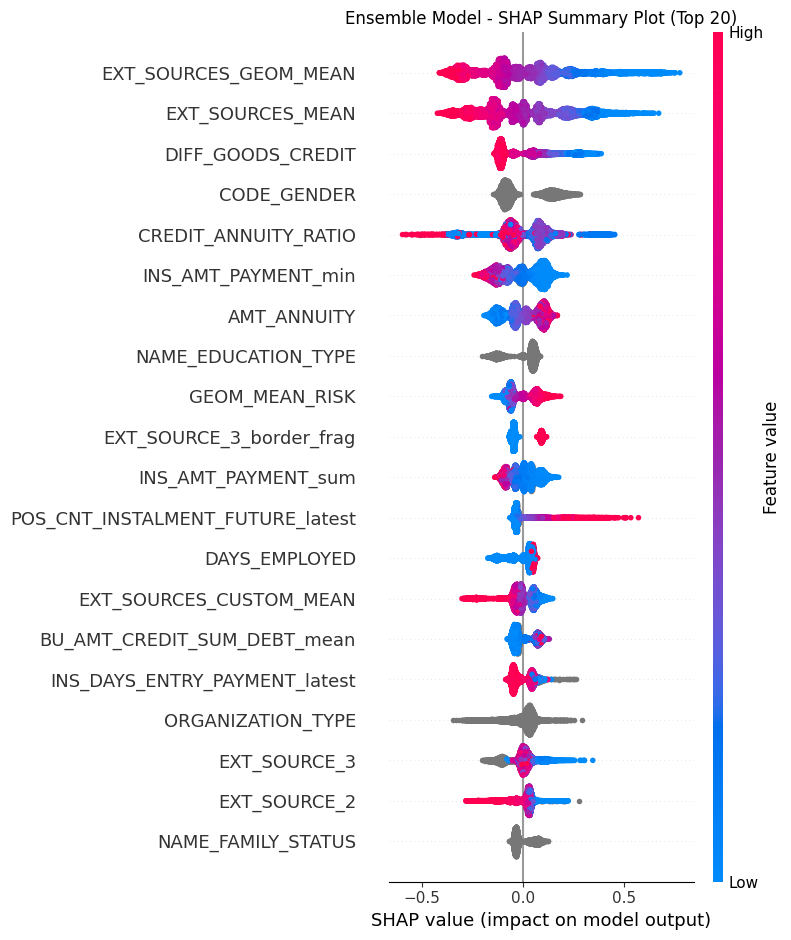


--- Ensemble SHAP Dependence Plot: EXT_SOURCES_GEOM_MEAN ---


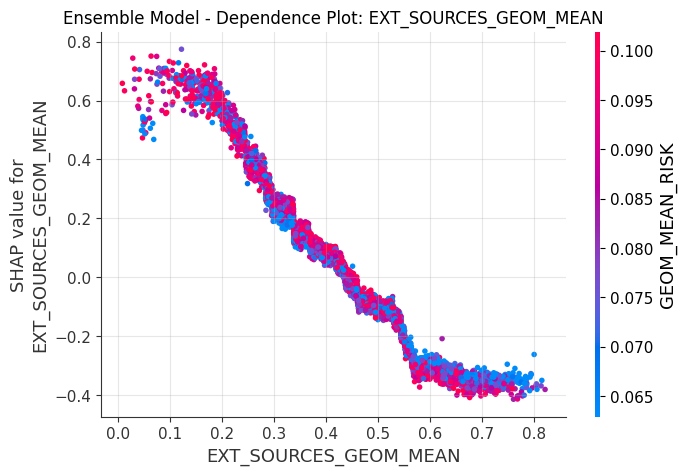


--- SHAP Dependence Plot: EXT_SOURCES_MEAN ---


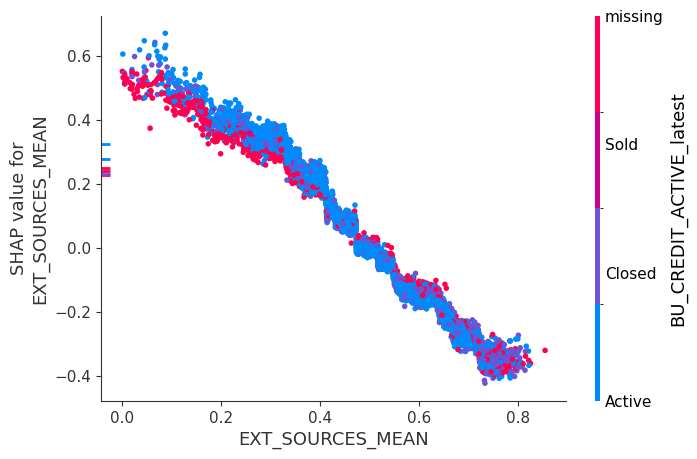

In [29]:
#3-4　SHAP　可視化1 (Summary Plot & Dependence Plot)

title_prefix = "Ensemble" if is_ensemble_shap else "LightGBM"

print(f"\n--- {title_prefix} SHAP Summary Plot ---")
# モデルが「貸し倒れ（TARGET=1）」と判断するのに効いている変数TOP20
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_ensemble,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title(f"{title_prefix} Model - SHAP Summary Plot (Top 20)")
plt.tight_layout()
plt.show()

# --- Dependence Plot (最も重要な特徴量について) ---
# Summary Plotで1位だった特徴量を自動取得
top_feature = feature_names[np.abs(shap_values_ensemble).mean(0).argmax()]

print(f"\n--- {title_prefix} SHAP Dependence Plot: {top_feature} ---")
# 特徴量の値（横軸）とSHAP値（縦軸）の関係
# 相互作用がある変数を自動で色付け
shap.dependence_plot(
    top_feature,
    shap_values_ensemble,
    X_sample,
    feature_names=feature_names,
    show=False
)
plt.title(f"{title_prefix} Model - Dependence Plot: {top_feature}")
plt.grid(True, alpha=0.3)
plt.show()

# EXT_SOURCE
target_feat = 'EXT_SOURCES_MEAN'
if target_feat in feature_names:
     print(f"\n--- SHAP Dependence Plot: {target_feat} ---")
     shap.dependence_plot(target_feat, shap_values_ensemble, X_sample, show=False)
     plt.show()



*   Summary Plot  
寄与度5％以上となるEXT_SOURCES_GEOM_MEAN(幾何平均)とEXT_SOURCES_MEAN(平均)では概ね同程度の傾向にあるが、幾何平均の方が低スコアの密度が太く、高スコアの裾が長いことから、1つでも低スコアがあればリスク信号として拾いやすい性質を持つ。
*   SHAP Dependence Plot(幾何平均、平均)  
幾何平均ではSHAPの範囲がおよそ-0.4～+0.8であり、スコアが高くなるほどデフォルトリスクが低下。特に0.55あたりで急激に下がっている。一方で平均では-0.4～+0.6の範囲で比較的緩やかな減少なっている。このため、単体の指標としては幾何平均の方がより3種のスコアの特徴をより捉えられていると考えられる。
ただし、相互作用としては幾何平均とGEOM_RISK_MEAN(業種×職種×収入タイプのデフォルト率の幾何平均)の組み合わせとしてみると、高スコアでもGEOM_RISK_MEANの値は高いものが多く、外部スコアが高くても業種・職種由来のリスクが残るケースを捉えており、外部スコアだけでは拾えないリスク要因を補完している。一方で平均とBU_CREDIT_ACTIVE_latest(直近のローン状況)の組み合わせではSold（債権売却）またはmissing（履歴なし）の場合と傾向が一致しており、目検でも判断しやすい。CATでの寄与度が高いのもこの点による差だと思われる。



In [ ]:
#3-5　SHAP　可視化2 (DIFF_GOODS_CREDIT、ORGANIZATION_TYPE)

target_features = ['DIFF_GOODS_CREDIT', 'ORGANIZATION_TYPE']

for feat in target_features:
    if feat in feature_names:
        print(f"\n--- {title_prefix} SHAP Analysis: {feat} ---")

        # 描画サイズを少し大きめにして視認性を確保
        fig, ax = plt.subplots(figsize=(8, 5))

        # 標準の dependence_plot を実行
        # ax=ax を指定することで、matplotlibの細かい調整が可能になります
        shap.dependence_plot(
            feat,
            shap_values_ensemble,
            X_sample,
            feature_names=feature_names,
            show=False,
            ax=ax,
            alpha=0.6 # 点が重なっても見やすいように少し透明に
        )

        # タイトルの追加
        ax.set_title(f"{title_prefix} - Dependence Plot: {feat}", fontsize=14, pad=20)

        # カテゴリ変数の場合、X軸のラベル（業種名など）を回転させて読みやすくする
        is_categorical = (X_sample[feat].dtype == 'object' or X_sample[feat].dtype.name == 'category')
        if is_categorical:
            plt.xticks(rotation=45, ha='right', fontsize=9)
            # 業種が多いので、目盛りを間引かずに全部表示する設定
            ax.set_xticks(range(len(X_sample[feat].unique())))

        plt.grid(True, alpha=0.2, axis='y')
        plt.tight_layout()
        plt.show()


--- Ensemble SHAP Analysis: DIFF_GOODS_CREDIT ---
